# Running Distance Classifier

**Goal:** Predict the maximum race distance an individual can complete — **5K**, **10K**, **Half Marathon**, or **Marathon** — from their fitness and body-composition metrics.

This notebook walks through a full supervised-learning pipeline:

1. Generate a realistic synthetic dataset (no real data needed for the demo).
2. Exploratory data analysis (EDA).
3. Preprocessing & train/test split.
4. Train and compare three scikit-learn classifiers: **Logistic Regression**, **Random Forest**, and **Gradient Boosting**.
5. Evaluate with accuracy, classification report, confusion matrix, and cross-validation.
6. Inspect feature importance to understand *why* the model predicts what it does.
7. Make predictions for hypothetical new individuals.

> **Note on the synthetic data:** the generator below uses simplified relationships inspired by exercise physiology (VO₂ max, training volume, body composition). It is not a substitute for real athlete data, but it is structured enough that a classifier can learn meaningful patterns.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import make_pipeline
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')


Libraries loaded.


## 1. Generate Synthetic Fitness Data

We simulate `N` individuals with realistic ranges for each metric, then derive a continuous **endurance score** from those metrics. The score is binned into the four race-distance classes.

**Features**

| Feature | Description | Typical range |
|---|---|---|
| `age` | Years | 18–65 |
| `sex` | 0 = female, 1 = male | — |
| `weight_kg` | Body weight | 45–110 |
| `height_cm` | Height | 150–200 |
| `bmi` | Derived from weight/height | — |
| `body_fat_pct` | Body fat percentage | 8–35 |
| `muscle_mass_pct` | Skeletal muscle mass % | 25–50 |
| `resting_hr` | Resting heart rate (bpm) | 40–85 |
| `vo2_max` | Aerobic capacity (ml/kg/min) | 25–75 |
| `mile_time_min` | Best mile time (minutes) | 4.5–12.0 |
| `weekly_miles` | Avg miles/week recent training | 0–80 |
| `years_running` | Years of consistent running | 0–20 |

The **target** is `max_distance` ∈ {`5K`, `10K`, `Half Marathon`, `Marathon`}.


In [28]:
def generate_fitness_dataset(n_samples: int = 2000, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    # Demographics
    age = rng.integers(18, 66, size=n_samples)
    sex = rng.integers(0, 2, size=n_samples)  # 0 = F, 1 = M

    # Anthropometrics  (sex-conditioned means)
    height_cm = np.where(sex == 1,
                         rng.normal(178, 7, n_samples),
                         rng.normal(165, 6, n_samples)).clip(150, 200)
    weight_kg = np.where(sex == 1,
                         rng.normal(78, 11, n_samples),
                         rng.normal(64, 10, n_samples)).clip(45, 110)
    bmi = weight_kg / (height_cm / 100) ** 2

    # Body composition
    body_fat_pct = np.where(sex == 1,
                            rng.normal(18, 5, n_samples),
                            rng.normal(25, 5, n_samples)).clip(8, 38)
    muscle_mass_pct = np.where(sex == 1,
                               rng.normal(42, 4, n_samples),
                               rng.normal(35, 4, n_samples)).clip(25, 52)

    # Cardiovascular / performance
    resting_hr = rng.normal(65, 9, n_samples).clip(40, 90)
    years_running = rng.gamma(2.0, 2.0, n_samples).clip(0, 20)
    weekly_miles = (rng.gamma(2.0, 8.0, n_samples) + 0.7 * years_running).clip(0, 80)

    # VO2 max influenced by training, age, body comp, sex
    vo2_max = (
        45
        + 0.45 * weekly_miles
        + 0.6 * years_running
        - 0.25 * (age - 25).clip(min=0)
        - 0.35 * (body_fat_pct - 15)
        + 3 * sex
        + rng.normal(0, 3, n_samples)
    ).clip(25, 78)

    # Mile time anti-correlates with VO2 max & training
    mile_time_min = (
        12.0
        - 0.06 * vo2_max
        - 0.025 * weekly_miles
        + 0.015 * (age - 25).clip(min=0)
        + 0.02 * (body_fat_pct - 15)
        + rng.normal(0, 0.4, n_samples)
    ).clip(4.5, 13.0)

    df = pd.DataFrame({
        'age': age,
        'sex': sex,
        'weight_kg': weight_kg.round(1),
        'height_cm': height_cm.round(1),
        'bmi': bmi.round(1),
        'body_fat_pct': body_fat_pct.round(1),
        'muscle_mass_pct': muscle_mass_pct.round(1),
        'resting_hr': resting_hr.round(0).astype(int),
        'vo2_max': vo2_max.round(1),
        'mile_time_min': mile_time_min.round(2),
        'weekly_miles': weekly_miles.round(1),
        'years_running': years_running.round(1),
    })

    # Endurance score — weighted combo of meaningful predictors + noise
    score = (
        0.35 * (df['vo2_max'] - df['vo2_max'].mean()) / df['vo2_max'].std()
        + 0.30 * (df['weekly_miles'] - df['weekly_miles'].mean()) / df['weekly_miles'].std()
        + 0.15 * (df['years_running'] - df['years_running'].mean()) / df['years_running'].std()
        - 0.25 * (df['mile_time_min'] - df['mile_time_min'].mean()) / df['mile_time_min'].std()
        - 0.10 * (df['resting_hr'] - df['resting_hr'].mean()) / df['resting_hr'].std()
        - 0.10 * (df['body_fat_pct'] - df['body_fat_pct'].mean()) / df['body_fat_pct'].std()
        + rng.normal(0, 0.25, n_samples)  # noise so the problem isn't trivial
    )

    # Bin into 4 classes by quantile so we get balanced labels
    labels = ['5K', '10K', 'Half Marathon', 'Marathon']
    df['endurance_score'] = score
    df['max_distance'] = pd.qcut(score, q=4, labels=labels)
    return df


df = generate_fitness_dataset(n_samples=2000)
print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (2000, 14)


,age,sex,weight_kg,height_cm,bmi,body_fat_pct,muscle_mass_pct,resting_hr,vo2_max,mile_time_min,weekly_miles,years_running,endurance_score,max_distance
0,22,1,79.4,170.8,27.2,26.7,42.0,82,44.3,8.61,9.1,4.8,-1.034086,5K
1,55,0,62.6,160.4,24.3,25.8,37.5,86,48.6,9.30,23.7,5.2,-0.812494,5K
2,49,0,67.3,170.9,23.1,22.7,36.2,68,47.0,10.03,14.9,12.2,-0.029959,Half Marathon
3,39,0,70.8,161.2,27.2,38.0,37.4,67,51.9,9.30,18.6,12.8,0.108616,Half Marathon
4,38,1,91.7,173.9,30.3,9.2,41.3,68,47.8,9.51,3.4,1.2,-1.019125,5K


## 2. Exploratory Data Analysis

Class distribution:
max_distance
5K               500
10K              500
Half Marathon    500
Marathon         500
Name: count, dtype: int64


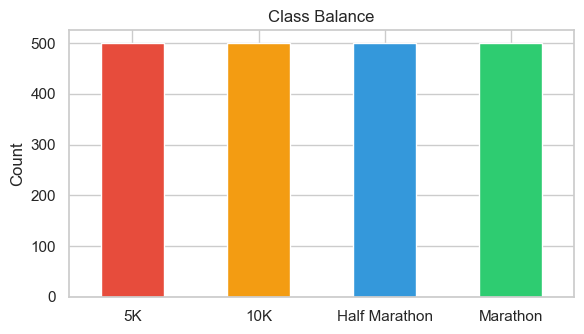

In [29]:
print('Class distribution:')
print(df['max_distance'].value_counts().reindex(['5K', '10K', 'Half Marathon', 'Marathon']))

fig, ax = plt.subplots(figsize=(6, 3.5))
df['max_distance'].value_counts().reindex(['5K', '10K', 'Half Marathon', 'Marathon']).plot(
    kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
)
ax.set_title('Class Balance')
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [30]:
df.describe().round(2)


,age,sex,weight_kg,height_cm,bmi,body_fat_pct,muscle_mass_pct,resting_hr,vo2_max,mile_time_min,weekly_miles,years_running,endurance_score
count,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,41.50,0.5,70.99,171.60,24.13,21.32,38.54,65.54,50.83,8.87,18.83,4.06,-0.00
std,13.93,0.5,12.54,9.25,4.00,6.04,5.27,9.04,7.85,0.90,11.53,2.85,0.93
min,18.00,0.0,45.00,150.00,12.70,8.00,25.00,40.00,29.10,5.25,0.90,0.10,-2.41
25%,29.00,0.0,62.08,164.80,21.40,17.00,34.80,59.00,45.60,8.32,10.58,2.00,-0.64
50%,42.00,0.0,70.90,170.90,24.00,21.30,38.50,66.00,50.30,8.93,16.50,3.50,-0.09
75%,54.00,1.0,79.22,178.20,26.70,25.50,42.30,72.00,55.60,9.49,24.60,5.40,0.55
max,65.00,1.0,110.00,199.60,38.50,38.00,52.00,90.00,78.00,11.50,79.90,18.70,4.13


C:\Users\justi\AppData\Local\Temp\ipykernel_14520\1263197707.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='max_distance', y=feat, order=order,
C:\Users\justi\AppData\Local\Temp\ipykernel_14520\1263197707.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='max_distance', y=feat, order=order,
C:\Users\justi\AppData\Local\Temp\ipykernel_14520\1263197707.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='max_distance', y=feat, order=order,
C:\Users\justi\AppData\Local\Temp\ipykernel_14520\1263197707.

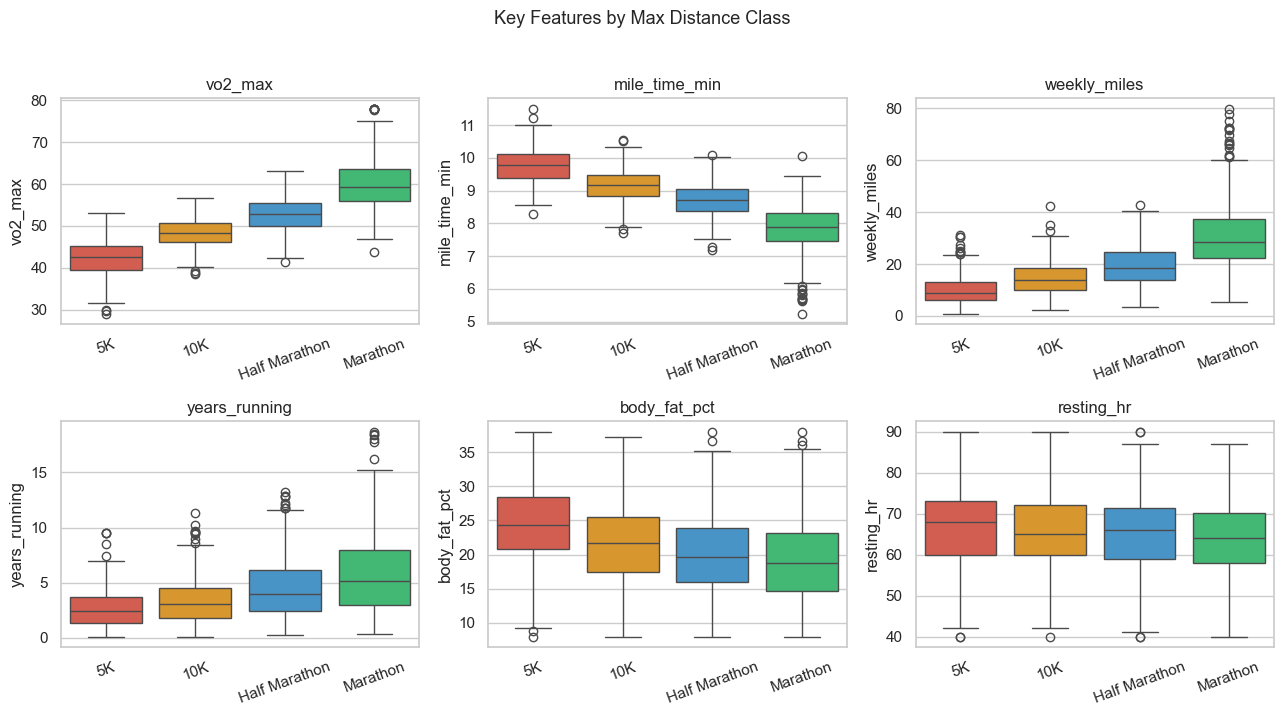

In [31]:
# Compare distributions of key features across the 4 classes
key_features = ['vo2_max', 'mile_time_min', 'weekly_miles', 'years_running',
                'body_fat_pct', 'resting_hr']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
order = ['5K', '10K', 'Half Marathon', 'Marathon']
palette = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=df, x='max_distance', y=feat, order=order,
                palette=palette, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Key Features by Max Distance Class', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


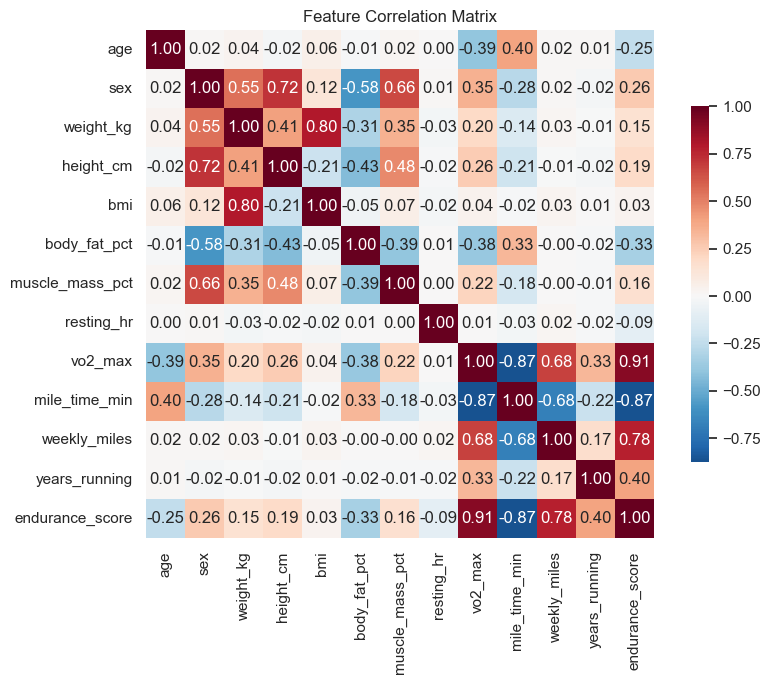

In [32]:
# Correlation heatmap of numeric features
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.drop(columns=['max_distance']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 3. Preprocessing & Train/Test Split

We encode the ordered target labels (5K → 0, 10K → 1, Half → 2, Marathon → 3), then stratify-split 80/20 so each class is represented proportionally in both sets. Features will be standardized inside a `Pipeline` for the models that need scaling.


In [33]:
feature_cols = [
    'age', 'sex', 'weight_kg', 'height_cm', 'bmi',
    'body_fat_pct', 'muscle_mass_pct', 'resting_hr',
    'vo2_max', 'mile_time_min', 'weekly_miles', 'years_running'
]
X = df[feature_cols].values
y_raw = df['max_distance'].astype(str).values

# Ordered label encoding so class indices reflect distance ordering
class_order = ['5K', '10K', 'Half Marathon', 'Marathon']
label_to_idx = {label: i for i, label in enumerate(class_order)}
y = np.array([label_to_idx[v] for v in y_raw])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes: {class_order}')


Train: (1600, 12)  |  Test: (400, 12)
Classes: ['5K', '10K', 'Half Marathon', 'Marathon']


## 4. Train & Compare Models

We compare three classifiers:

- **Logistic Regression** — strong linear baseline, interpretable coefficients.
- **Random Forest** — robust non-linear ensemble, handles feature interactions.
- **Gradient Boosting** — often the best on tabular data, builds trees sequentially.

Each is evaluated on the held-out test set and with 5-fold stratified cross-validation on the training set.


In [34]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=250, max_depth=3, learning_rate=0.07,
        random_state=RANDOM_STATE
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    results.append({
        'Model': name,
        'Test Accuracy': round(test_acc, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df


,Test Accuracy,CV Mean,CV Std
Model,,,
Logistic Regression,0.7850,0.7550,0.0243
Random Forest,0.7475,0.7150,0.0278
Gradient Boosting,0.7175,0.7056,0.0351


In [35]:
# Pick the best model by test accuracy
best_name = results_df['Test Accuracy'].idxmax()
best_model = fitted[best_name]
print(f'Best model: {best_name}  (Test Acc = {results_df.loc[best_name, "Test Accuracy"]:.3f})')


Best model: Logistic Regression  (Test Acc = 0.785)


## 5. Evaluate the Best Model

A four-class problem benefits from looking beyond raw accuracy. We inspect:

- **Classification report** — precision, recall, F1 per class.
- **Confusion matrix** — where the model confuses adjacent classes (e.g. 10K vs Half).


In [36]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_order, digits=3))


               precision    recall  f1-score   support

           5K      0.894     0.840     0.866       100
          10K      0.679     0.720     0.699       100
Half Marathon      0.708     0.680     0.694       100
     Marathon      0.865     0.900     0.882       100

     accuracy                          0.785       400
    macro avg      0.787     0.785     0.785       400
 weighted avg      0.787     0.785     0.785       400



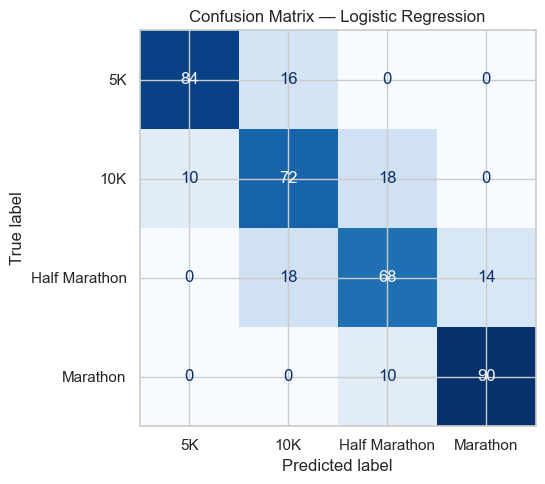

In [37]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()


## 6. Feature Importance

For tree-based models we use the model's built-in importance scores. These tell us **which fitness metrics the classifier leans on most** when predicting distance class.


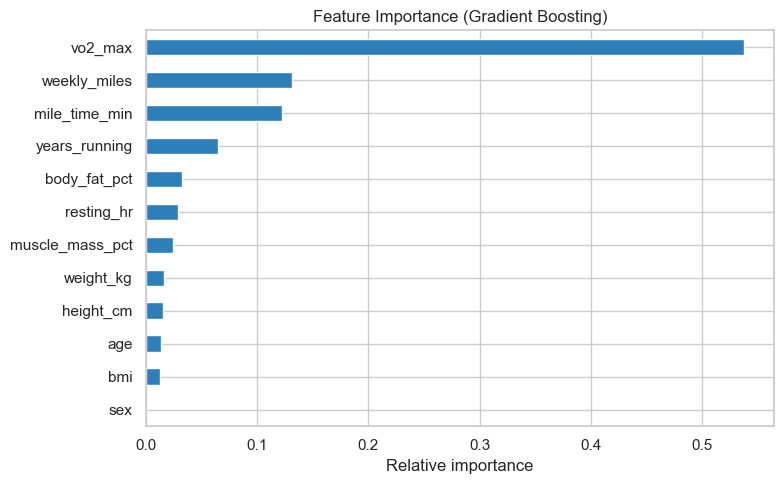

,importance
vo2_max,0.538
weekly_miles,0.132
mile_time_min,0.122
years_running,0.065
body_fat_pct,0.032
resting_hr,0.028
muscle_mass_pct,0.024
weight_kg,0.016
height_cm,0.016
age,0.014


In [38]:
# Use the tree model that exposes feature_importances_
tree_model = fitted.get('Gradient Boosting') or fitted.get('Random Forest')
importances = pd.Series(tree_model.feature_importances_, index=feature_cols)\
    .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#2c7fb8', ax=ax)
ax.set_title('Feature Importance (Gradient Boosting)')
ax.set_xlabel('Relative importance')
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False).to_frame('importance').round(3)


## 7. Predict for New Individuals

Let's run inference for three hypothetical people to sanity-check the model.


In [39]:
def predict_distance(model, person: dict) -> str:
    """Predict the max race distance for a single person dict."""
    x = np.array([[person[c] for c in feature_cols]])
    pred_idx = int(model.predict(x)[0])
    proba = model.predict_proba(x)[0] if hasattr(model, 'predict_proba') else None
    print(f"Predicted: {class_order[pred_idx]}")
    if proba is not None:
        for cls, p in zip(class_order, proba):
            print(f"  P({cls:<14}) = {p:.3f}")
    return class_order[pred_idx]


casual_jogger = {
    'age': 32, 'sex': 1, 'weight_kg': 82, 'height_cm': 178, 'bmi': 25.9,
    'body_fat_pct': 22, 'muscle_mass_pct': 38, 'resting_hr': 70,
    'vo2_max': 42, 'mile_time_min': 9.5, 'weekly_miles': 8, 'years_running': 1.5,
}
serious_runner = {
    'age': 29, 'sex': 0, 'weight_kg': 58, 'height_cm': 168, 'bmi': 20.5,
    'body_fat_pct': 18, 'muscle_mass_pct': 38, 'resting_hr': 52,
    'vo2_max': 58, 'mile_time_min': 6.5, 'weekly_miles': 35, 'years_running': 6,
}
elite_marathoner = {
    'age': 27, 'sex': 1, 'weight_kg': 65, 'height_cm': 175, 'bmi': 21.2,
    'body_fat_pct': 9, 'muscle_mass_pct': 45, 'resting_hr': 42,
    'vo2_max': 72, 'mile_time_min': 5.0, 'weekly_miles': 65, 'years_running': 12,
}

print('--- Casual jogger ---')
predict_distance(best_model, casual_jogger)
print('\n--- Serious recreational runner ---')
predict_distance(best_model, serious_runner)
print('\n--- Elite marathoner ---')
predict_distance(best_model, elite_marathoner)


--- Casual jogger ---
Predicted: 5K
  P(5K            ) = 0.880
  P(10K           ) = 0.120
  P(Half Marathon ) = 0.001
  P(Marathon      ) = 0.000

--- Serious recreational runner ---
Predicted: Marathon
  P(5K            ) = 0.000
  P(10K           ) = 0.000
  P(Half Marathon ) = 0.000
  P(Marathon      ) = 1.000

--- Elite marathoner ---
Predicted: Marathon
  P(5K            ) = 0.000
  P(10K           ) = 0.000
  P(Half Marathon ) = 0.000
  P(Marathon      ) = 1.000


'Marathon'

## 8. Hyperparameter Finetuning Using GridSearchCV

We will be using GridSearch CV with our Logistic Regression Model




In [40]:
SCORING = 'accuracy'        
lr_pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))

lr_grid = {
    'logisticregression__C':       [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2'],
    'logisticregression__solver':  ['lbfgs'],
    'logisticregression__class_weight': [None, 'balanced'],
}

lr_search = GridSearchCV(lr_pipe, lr_grid, cv=cv, scoring=SCORING, n_jobs=-1)

lr_search.fit(X_train, y_train)
print('LR best params :', lr_search.best_params_)
print('LR best CV acc :', round(lr_search.best_score_, 4))
print('LR test acc:', round(accuracy_score(y_test, lr_search.best_estimator_.predict(X_test)), 4))

LR best params : {'logisticregression__C': 1, 'logisticregression__class_weight': None, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs'}
LR best CV acc : 0.755
LR test acc: 0.785


C:\Users\justi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 9. Hyperparameter Finetuning Using RandomizedSearchCV

We will be using RandomizedSearchCV with our Random Forest Model


In [41]:
rf_dist = {
    'n_estimators':      [200, 400, 600, 800, 1000],
    'max_depth':         [None, 8, 12, 16, 24],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_dist, n_iter=80, cv=cv, scoring=SCORING,
    n_jobs=-1, random_state=RANDOM_STATE)

rf_search.fit(X_train, y_train)
print('RF best params :', rf_search.best_params_)
print('RF best CV acc :', round(rf_search.best_score_, 4))
print('RF test acc:', round(accuracy_score(y_test, rf_search.best_estimator_.predict(X_test)), 4))

RF best params : {'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 16}
RF best CV acc : 0.7225
RF test acc: 0.7475


## 10. Hyperparameter Finetuning Using RandomizedSearchCV with Gradient Boosting

We will be using RandomizedSearchCV with our Random Forest Model and Gradient Boosting Classifier


In [45]:
gb_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.003, 0.005, 0.01, 0.02],
    'max_depth':         [2, 3, 4, 5],
    'subsample':         [0.7, 0.85, 1.0],
    'min_samples_split': [2, 5, 10],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_dist, n_iter=40, cv=cv, scoring=SCORING,
    n_jobs=-1, random_state=RANDOM_STATE)

gb_search.fit(X_train, y_train)
print('GB best params :', gb_search.best_params_)
print('GB best CV acc :', round(gb_search.best_score_, 4))
print('GB test acc:', round(accuracy_score(y_test, gb_search.best_estimator_.predict(X_test)), 4))

GB best params : {'subsample': 0.85, 'n_estimators': 500, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.01}
GB best CV acc : 0.7231
GB test acc: 0.7525


## 11. Compare Model Performance Improvement using cross-validation

Compare the three best CV scores side-by-side.

In [43]:
results = pd.DataFrame({
    'model':     ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'cv_best':   [lr_search.best_score_, rf_search.best_score_, gb_search.best_score_],
})
print(results.sort_values('cv_best', ascending=False))

# pick the winner by CV score
winners = {'Logistic Regression': lr_search,
           'Random Forest':       rf_search,
           'Gradient Boosting':   gb_search}
best_name   = results.sort_values('cv_best', ascending=False).iloc[0]['model']
best_model  = winners[best_name].best_estimator_

print(f'\nBest by CV: {best_name}')
print('Holdout accuracy :', round(accuracy_score(y_test, best_model.predict(X_test)), 4))
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=class_order, digits=3))
print(confusion_matrix(y_test, best_model.predict(X_test)))

                 model   cv_best
0  Logistic Regression  0.755000
2    Gradient Boosting  0.723125
1        Random Forest  0.722500

Best by CV: Logistic Regression
Holdout accuracy : 0.785
               precision    recall  f1-score   support

           5K      0.894     0.840     0.866       100
          10K      0.679     0.720     0.699       100
Half Marathon      0.708     0.680     0.694       100
     Marathon      0.865     0.900     0.882       100

     accuracy                          0.785       400
    macro avg      0.787     0.785     0.785       400
 weighted avg      0.787     0.785     0.785       400

[[84 16  0  0]
 [10 72 18  0]
 [ 0 18 68 14]
 [ 0  0 10 90]]


## 12. Compare Model Performance Improvement using cross-validation

In [44]:
def inspect_search(name, search, param_cols, top_n=10):
    df = pd.DataFrame(search.cv_results_)
    cols = ['mean_test_score', 'std_test_score'] + param_cols
    print(f'\n--- {name} (top {top_n}) ---')
    print(df[cols].sort_values('mean_test_score', ascending=False).head(top_n))

inspect_search('Logistic Regression', lr_search,
               ['param_logisticregression__C',
                'param_logisticregression__penalty',
                'param_logisticregression__class_weight'])
inspect_search('Random Forest', rf_search,
               ['param_n_estimators', 'param_max_depth',
                'param_min_samples_split', 'param_min_samples_leaf',
                'param_max_features'])
inspect_search('Gradient Boosting', gb_search,
               ['param_learning_rate', 'param_max_depth',
                'param_n_estimators', 'param_subsample'])


--- Logistic Regression (top 10) ---
   mean_test_score  std_test_score  param_logisticregression__C  \
4         0.755000        0.024255                         1.00   
5         0.755000        0.024255                         1.00   
2         0.752500        0.017722                         0.10   
3         0.752500        0.017722                         0.10   
6         0.751875        0.023184                        10.00   
7         0.751875        0.023184                        10.00   
8         0.750625        0.023335                       100.00   
9         0.750625        0.023335                       100.00   
0         0.725000        0.020059                         0.01   
1         0.725000        0.020059                         0.01   

  param_logisticregression__penalty param_logisticregression__class_weight  
4                                l2                                   None  
5                                l2                               bala